<a href="https://colab.research.google.com/github/10decn/lab-2/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

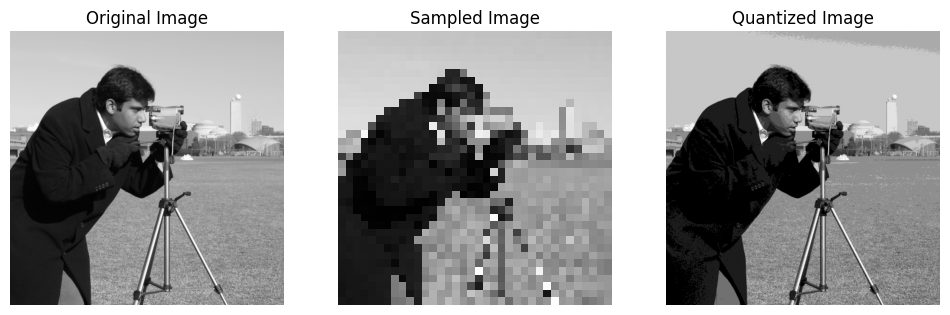

In [3]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

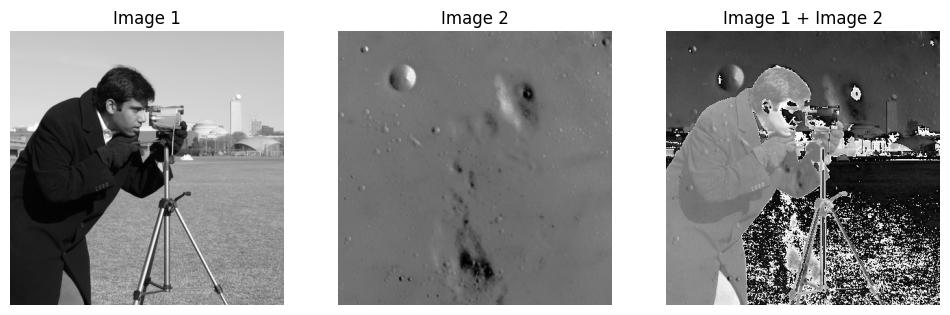

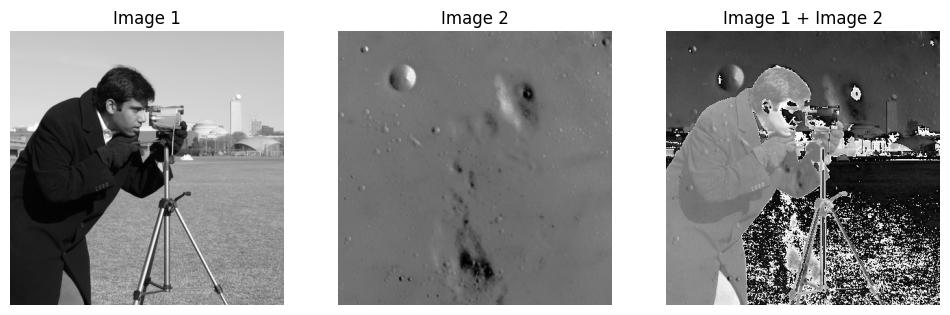

In [5]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

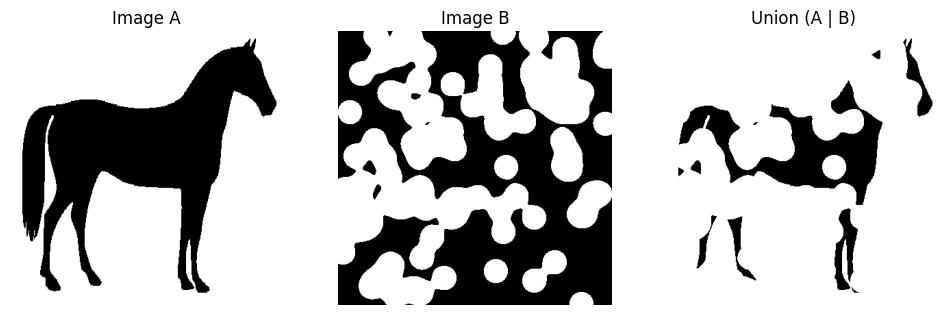

In [7]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

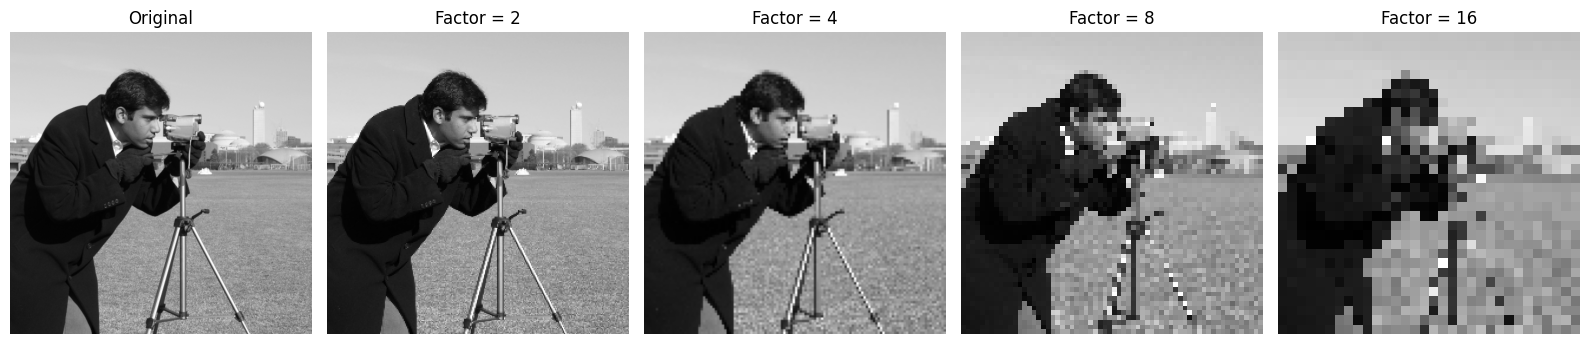

In [8]:
sampling_factors = [2, 4, 8, 16]

plt.figure(figsize=(16, 4))
plt.subplot(1, 5, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, factor in enumerate(sampling_factors, start=2):
    sampled = sample_image(original_image, factor)
    plt.subplot(1, 5, i)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'Factor = {factor}')
    plt.axis('off')

plt.tight_layout()
plt.show()


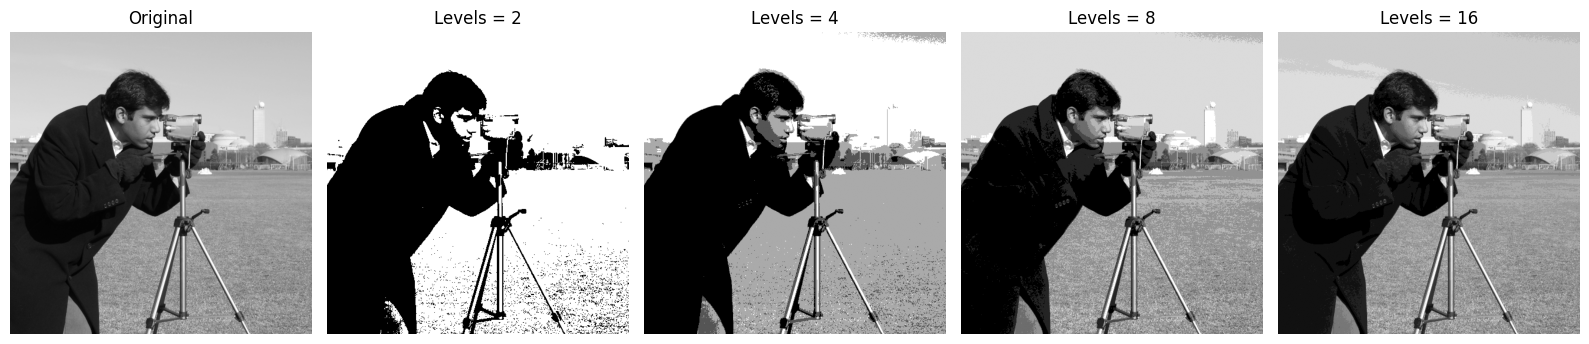

In [9]:
quantization_levels_list = [2, 4, 8, 16]

plt.figure(figsize=(16, 4))
plt.subplot(1, 5, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, levels in enumerate(quantization_levels_list, start=2):
    quantized = quantize_image(original_image, levels)
    plt.subplot(1, 5, i)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'Levels = {levels}')
    plt.axis('off')

plt.tight_layout()
plt.show()


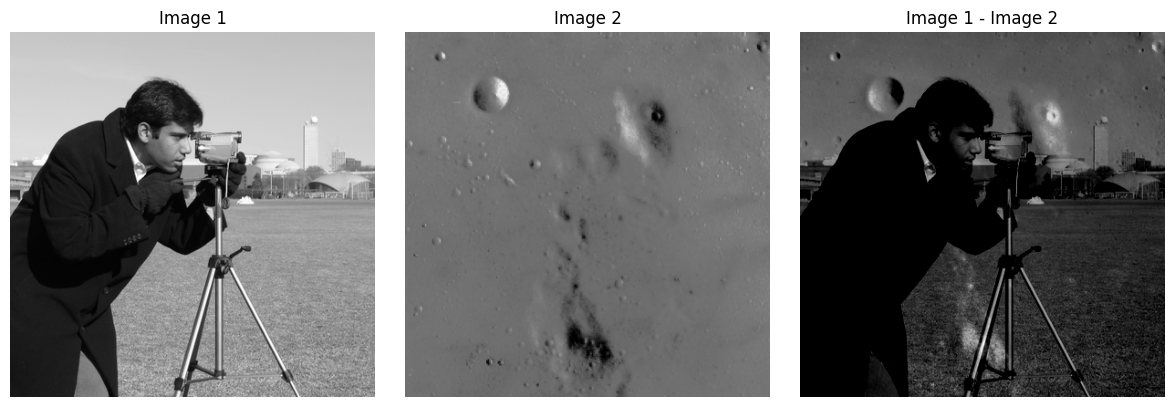

In [10]:
im1_int = im1arr.astype(np.int16)
im2_int = im2arr.astype(np.int16)

subtraction = np.clip(im1_int - im2_int, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(im1arr, cmap='gray')
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(im2arr, cmap='gray')
plt.title('Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(subtraction, cmap='gray')
plt.title('Image 1 - Image 2')
plt.axis('off')

plt.tight_layout()
plt.show()


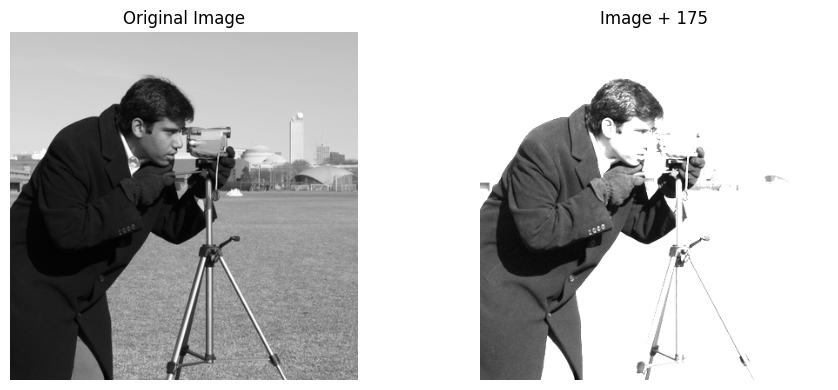

In [11]:
constant = 175

added_constant = np.clip(im1arr.astype(np.int16) + constant, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(im1arr, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(added_constant, cmap='gray')
plt.title('Image + 175')
plt.axis('off')

plt.tight_layout()
plt.show()


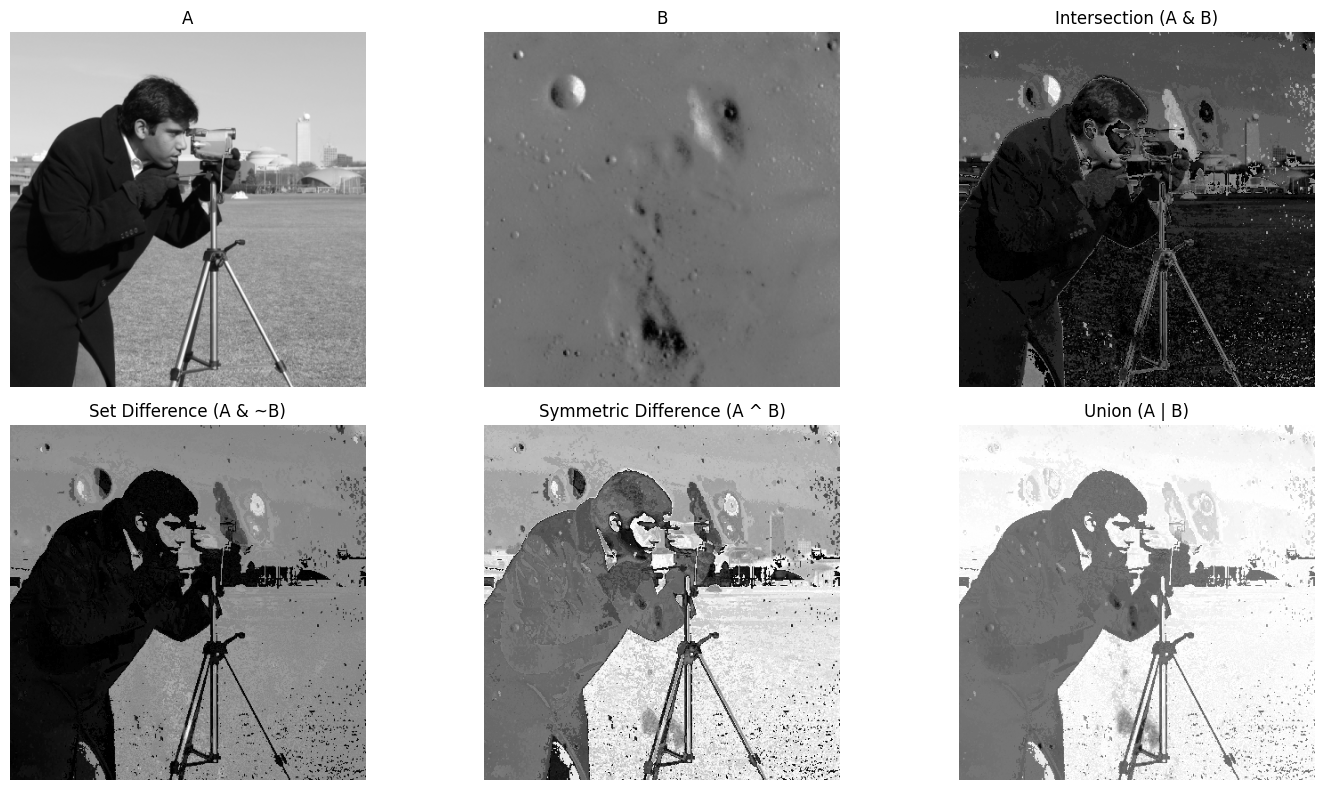

In [12]:
A = data.camera()
B = data.moon()

A = cv2.resize(A, new_size, interpolation=cv2.INTER_AREA)
B = cv2.resize(B, new_size, interpolation=cv2.INTER_AREA)

intersection = A & B
set_difference = A & (~B)
symmetric_difference = A ^ B
union = A | B

plt.figure(figsize=(15, 8))

images = [
    (A, 'A'),
    (B, 'B'),
    (intersection, 'Intersection (A & B)'),
    (set_difference, 'Set Difference (A & ~B)'),
    (symmetric_difference, 'Symmetric Difference (A ^ B)'),
    (union, 'Union (A | B)')
]

for i, (image, title) in enumerate(images, start=1):
    plt.subplot(2, 3, i)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()
